# 第四章：循環神經網路的正規化
## Recurrent Neural Network Regularization - PyTorch 實作

**原始論文：** Zaremba, Sutskever, Vinyals (2014)

本 Notebook 實作 RNN 的正確 Dropout 方法，並比較不同策略的效果。

In [16]:
# 跨平台中文字型設定（支援 Colab、VSCode、Antigravity 等本地環境）
import subprocess
import os
import shutil
import platform

system = platform.system()

# 必須在 import matplotlib 之前清除快取
cache_dir = os.path.expanduser('~/.matplotlib')
if os.path.exists(cache_dir):
    for f in os.listdir(cache_dir):
        if f.startswith('fontlist'):
            try:
                os.remove(os.path.join(cache_dir, f))
            except:
                pass

cache_dir2 = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir2):
    shutil.rmtree(cache_dir2, ignore_errors=True)

# Linux/Colab 環境安裝中文字型
if system == 'Linux' or 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    try:
        result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
        if 'Noto Sans CJK' not in result.stdout:
            print("正在安裝中文字型...")
            subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
            subprocess.run(['apt-get', 'install', '-qq', '-y', 'fonts-noto-cjk'], capture_output=True)
            print("中文字型安裝完成，請重新啟動 kernel")
    except:
        pass

print(f"✓ {system} 環境")

✓ Darwin 環境：使用系統內建中文字型


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 重建字型快取並設定中文字型
from matplotlib.font_manager import fontManager
fontManager.__init__()

chinese_fonts = [
    'Heiti TC', 'PingFang TC', 'Noto Sans CJK TC',
    'Heiti SC', 'PingFang SC', 'Noto Sans CJK SC', 
    'Microsoft JhengHei', 'Microsoft YaHei',
    'SimHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS',
]

available_fonts = set(f.name for f in fontManager.ttflist)
selected_font = None
for font in chinese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [selected_font] + chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✓ 使用中文字型: {selected_font}")
else:
    plt.rcParams['font.sans-serif'] = chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print("⚠ 使用預設字型列表")

import numpy as np
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 跨平台中文字型設定
# 字型優先順序：涵蓋 Mac, Windows, Linux, Colab 常見中文字型
chinese_fonts = [
    'Noto Sans CJK TC',      # Linux/Colab/Mac(安裝後)
    'Noto Sans CJK SC',      # Linux/Colab/Mac(安裝後) 簡體
    'Heiti TC',              # Mac 內建 繁體
    'Heiti SC',              # Mac 內建 簡體
    'PingFang TC',           # Mac 內建 繁體
    'PingFang SC',           # Mac 內建 簡體
    'Microsoft JhengHei',    # Windows 微軟正黑體 繁體
    'Microsoft YaHei',       # Windows 微軟雅黑 簡體
    'SimHei',                # Windows 黑體
    'WenQuanYi Micro Hei',   # Linux 文泉驛微米黑
    'Droid Sans Fallback',   # Android/舊版 Linux
    'Arial Unicode MS',      # 跨平台 Unicode 字型
    'DejaVu Sans',           # 後備字型
]

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = chinese_fonts
plt.rcParams['axes.unicode_minus'] = False  # 正確顯示負號

# 驗證字型設定
def verify_chinese_font():
    """驗證中文字型是否正確載入"""
    from matplotlib.font_manager import FontManager
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in chinese_fonts:
        if font in available:
            print(f"✓ 使用中文字型: {font}")
            return font
    print("⚠ 警告：未找到中文字型，中文可能無法正確顯示")
    return None

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch 版本: {torch.__version__}")
print(f"使用裝置: {device}")
verify_chinese_font()

PyTorch 版本: 2.9.1
使用裝置: cpu
✓ 使用中文字型: Heiti TC


'Heiti TC'

## 1. 標準 Dropout 實作

首先理解標準 Dropout 的工作原理：
- 訓練時：以機率 $p$ 將神經元設為 0，並將保留的值除以 $(1-p)$
- 測試時：不做任何修改（因為訓練時已經縮放）

In [18]:
def manual_dropout(x, p=0.5, training=True):
    """
    手動實作 Inverted Dropout
    
    參數:
        x: 輸入張量
        p: dropout 機率（丟棄的比例）
        training: 是否在訓練模式
    """
    if not training or p == 0:
        return x
    
    # 生成伯努利遮罩
    mask = (torch.rand_like(x) > p).float()
    # 縮放：保持期望值不變
    return x * mask / (1 - p)

# 測試 Dropout
x = torch.ones(1, 10)
print("原始輸入:", x.numpy())
print("\nDropout (p=0.5) 多次執行:")
for i in range(3):
    dropped = manual_dropout(x, p=0.5, training=True)
    print(f"  第 {i+1} 次: {dropped.numpy()}, 平均值: {dropped.mean():.2f}")

print(f"\n測試模式: {manual_dropout(x, p=0.5, training=False).numpy()}")
print("(測試模式不做修改，因為訓練時已經縮放過)")

原始輸入: [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]

Dropout (p=0.5) 多次執行:
  第 1 次: [[2. 2. 0. 2. 0. 2. 0. 2. 2. 0.]], 平均值: 1.20
  第 2 次: [[2. 2. 2. 2. 2. 0. 2. 2. 0. 2.]], 平均值: 1.60
  第 3 次: [[0. 0. 0. 2. 0. 0. 0. 0. 2. 0.]], 平均值: 0.40

測試模式: [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
(測試模式不做修改，因為訓練時已經縮放過)


## 2. RNN 中 Dropout 的錯誤用法

讓我們先展示**錯誤**的做法：對循環連接應用 Dropout

In [19]:
class RNNWithWrongDropout(nn.Module):
    """
    錯誤示範：對循環連接也應用 dropout
    這會破壞時間上的資訊流動！
    """
    def __init__(self, input_size, hidden_size, output_size, dropout_p=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        self.dropout_p = dropout_p
        
        self.W_xh = nn.Linear(input_size, hidden_size, bias=False)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_hy = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)
    
    def forward(self, x, h=None):
        # x: (batch, seq_len, input_size)
        batch_size, seq_len, _ = x.shape
        
        if h is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        
        outputs = []
        hidden_states = []
        
        for t in range(seq_len):
            # 錯誤！對循環連接也應用 dropout
            h_dropped = self.dropout(h)  # ← 這是問題所在！
            
            h = torch.tanh(
                self.W_xh(x[:, t, :]) + 
                self.W_hh(h_dropped) +  # 使用了 dropped 的 h
                0  # bias
            )
            hidden_states.append(h.detach())
            
            y = self.W_hy(h)
            outputs.append(y)
        
        return torch.stack(outputs, dim=1), hidden_states

print("RNNWithWrongDropout: 對循環連接應用 dropout（錯誤做法）")

RNNWithWrongDropout: 對循環連接應用 dropout（錯誤做法）


## 3. 正確的 RNN Dropout（Zaremba et al.）

**核心思想**：只對輸入和輸出連接應用 dropout，**不對**循環連接應用！

In [20]:
class RNNWithCorrectDropout(nn.Module):
    """
    正確實作：只對輸入和輸出應用 dropout
    循環連接（h_{t-1} -> h_t）不應用 dropout
    """
    def __init__(self, input_size, hidden_size, output_size, dropout_p=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        self.dropout_p = dropout_p
        
        self.W_xh = nn.Linear(input_size, hidden_size, bias=False)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_hy = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)
    
    def forward(self, x, h=None):
        # x: (batch, seq_len, input_size)
        batch_size, seq_len, _ = x.shape
        
        if h is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        
        outputs = []
        hidden_states = []
        
        for t in range(seq_len):
            # 對輸入應用 dropout
            x_dropped = self.dropout(x[:, t, :])  # ✓ 正確
            
            # 循環連接不應用 dropout！
            h = torch.tanh(
                self.W_xh(x_dropped) +  # 使用 dropped 的輸入
                self.W_hh(h) +           # 直接使用 h，不 drop！
                0
            )
            hidden_states.append(h.detach())
            
            # 對輸出應用 dropout
            h_dropped = self.dropout(h)  # ✓ 正確
            y = self.W_hy(h_dropped)
            outputs.append(y)
        
        return torch.stack(outputs, dim=1), hidden_states

print("RNNWithCorrectDropout: 只對輸入和輸出應用 dropout（正確做法）")

RNNWithCorrectDropout: 只對輸入和輸出應用 dropout（正確做法）


## 4. 變分 Dropout（Variational Dropout）

**改進**：對整個序列使用**相同的** dropout 遮罩！

In [21]:
class VariationalDropout(nn.Module):
    """
    變分 Dropout：對整個序列使用相同的遮罩
    
    理論依據：從貝葉斯角度，這相當於對權重的變分推斷
    """
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p
        self._mask = None
    
    def reset_mask(self, x):
        """為新序列生成遮罩"""
        if self.training and self.p > 0:
            # 生成單一遮罩，shape: (batch, 1, features)
            # 這個遮罩會被廣播到所有時間步
            mask = torch.bernoulli(
                torch.ones(x.size(0), 1, x.size(-1), device=x.device) * (1 - self.p)
            )
            self._mask = mask / (1 - self.p)
        else:
            self._mask = None
    
    def forward(self, x):
        if self._mask is None:
            return x
        return x * self._mask


class RNNWithVariationalDropout(nn.Module):
    """
    使用變分 Dropout 的 RNN
    """
    def __init__(self, input_size, hidden_size, output_size, dropout_p=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.W_xh = nn.Linear(input_size, hidden_size, bias=False)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_hy = nn.Linear(hidden_size, output_size)
        
        self.input_dropout = VariationalDropout(dropout_p)
        self.output_dropout = VariationalDropout(dropout_p)
    
    def forward(self, x, h=None):
        batch_size, seq_len, input_size = x.shape
        
        if h is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        
        # 為這個序列生成遮罩（整個序列使用相同遮罩）
        self.input_dropout.reset_mask(x)
        # 為輸出也準備遮罩
        h_dummy = torch.zeros(batch_size, 1, self.hidden_size, device=x.device)
        self.output_dropout.reset_mask(h_dummy)
        
        outputs = []
        hidden_states = []
        
        for t in range(seq_len):
            # 應用相同的輸入遮罩
            x_t = x[:, t:t+1, :]
            x_dropped = self.input_dropout(x_t).squeeze(1)
            
            h = torch.tanh(
                self.W_xh(x_dropped) +
                self.W_hh(h)  # 循環連接不 drop
            )
            hidden_states.append(h.detach())
            
            # 應用相同的輸出遮罩
            h_for_output = h.unsqueeze(1)
            h_dropped = self.output_dropout(h_for_output).squeeze(1)
            y = self.W_hy(h_dropped)
            outputs.append(y)
        
        return torch.stack(outputs, dim=1), hidden_states

print("RNNWithVariationalDropout: 使用一致遮罩的變分 dropout")

RNNWithVariationalDropout: 使用一致遮罩的變分 dropout


## 5. 比較不同 Dropout 策略

讓我們視覺化不同策略對隱藏狀態的影響：

In [22]:
# 建立三個模型
input_size = 10
hidden_size = 20
output_size = 10
dropout_p = 0.5

model_wrong = RNNWithWrongDropout(input_size, hidden_size, output_size, dropout_p)
model_correct = RNNWithCorrectDropout(input_size, hidden_size, output_size, dropout_p)
model_var = RNNWithVariationalDropout(input_size, hidden_size, output_size, dropout_p)

# 設為訓練模式
model_wrong.train()
model_correct.train()
model_var.train()

# 使用更長的序列來展示差異
seq_length = 100
batch_size = 1
test_input = torch.randn(batch_size, seq_length, input_size)

# 多次執行來觀察變異
num_runs = 20

def get_hidden_norms(model, x, num_runs):
    """執行多次並收集隱藏狀態的範數"""
    all_norms = []
    for _ in range(num_runs):
        with torch.no_grad():
            _, h_states = model(x)
        # 計算每個時間步的隱藏狀態範數
        norms = [h.norm().item() for h in h_states]
        all_norms.append(norms)
    return np.array(all_norms)

# 收集數據
norms_wrong = get_hidden_norms(model_wrong, test_input, num_runs)
norms_correct = get_hidden_norms(model_correct, test_input, num_runs)
norms_var = get_hidden_norms(model_var, test_input, num_runs)

print(f"序列長度: {seq_length}")
print(f"執行次數: {num_runs}")
print(f"隱藏狀態範數矩陣形狀: {norms_wrong.shape} (執行次數, 時間步)")

序列長度: 100
執行次數: 20
隱藏狀態範數矩陣形狀: (20, 100) (執行次數, 時間步)


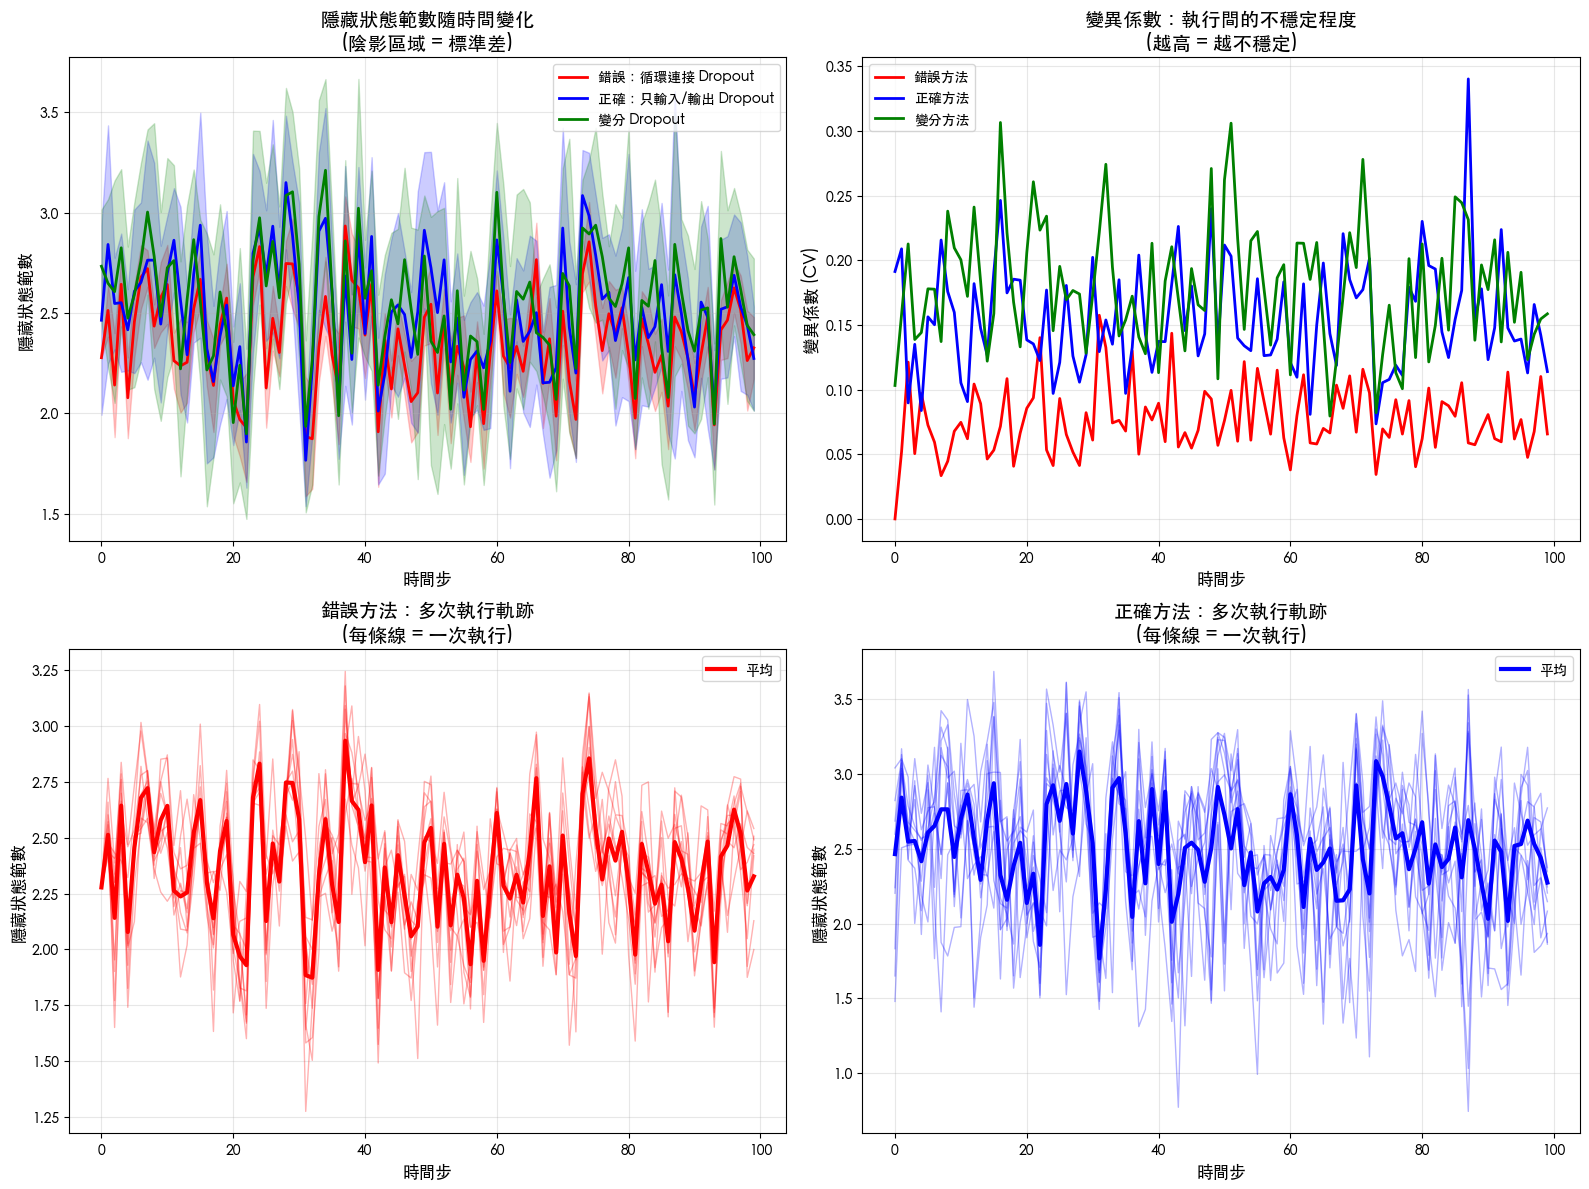


觀察重點:
• 錯誤方法：隱藏狀態範數變化劇烈，多次執行差異大（紅色陰影寬）
• 正確方法：範數相對穩定，多次執行較一致（藍色陰影窄）
• 變分方法：最穩定，因為每次執行內部遮罩一致（綠色陰影最窄）

最終變異係數 (t=100):
  錯誤方法: 0.0657
  正確方法: 0.1139
  變分方法: 0.1585


In [23]:
# 視覺化比較
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

time_steps = np.arange(seq_length)

# 上左：隱藏狀態範數隨時間變化（平均值 ± 標準差）
ax = axes[0, 0]
for norms, label, color in [
    (norms_wrong, '錯誤：循環連接 Dropout', 'red'),
    (norms_correct, '正確：只輸入/輸出 Dropout', 'blue'),
    (norms_var, '變分 Dropout', 'green')
]:
    mean = norms.mean(axis=0)
    std = norms.std(axis=0)
    ax.plot(time_steps, mean, label=label, color=color, linewidth=2)
    ax.fill_between(time_steps, mean - std, mean + std, color=color, alpha=0.2)

ax.set_xlabel('時間步', fontsize=12)
ax.set_ylabel('隱藏狀態範數', fontsize=12)
ax.set_title('隱藏狀態範數隨時間變化\n(陰影區域 = 標準差)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 上右：變異係數（標準差/平均值）
ax = axes[0, 1]
cv_wrong = norms_wrong.std(axis=0) / (norms_wrong.mean(axis=0) + 1e-8)
cv_correct = norms_correct.std(axis=0) / (norms_correct.mean(axis=0) + 1e-8)
cv_var = norms_var.std(axis=0) / (norms_var.mean(axis=0) + 1e-8)

ax.plot(time_steps, cv_wrong, 'r-', label='錯誤方法', linewidth=2)
ax.plot(time_steps, cv_correct, 'b-', label='正確方法', linewidth=2)
ax.plot(time_steps, cv_var, 'g-', label='變分方法', linewidth=2)

ax.set_xlabel('時間步', fontsize=12)
ax.set_ylabel('變異係數 (CV)', fontsize=12)
ax.set_title('變異係數：執行間的不穩定程度\n(越高 = 越不穩定)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 下左：多次執行的軌跡（錯誤方法）
ax = axes[1, 0]
for i in range(min(10, num_runs)):
    ax.plot(time_steps, norms_wrong[i], 'r-', alpha=0.3, linewidth=1)
ax.plot(time_steps, norms_wrong.mean(axis=0), 'r-', linewidth=3, label='平均')
ax.set_xlabel('時間步', fontsize=12)
ax.set_ylabel('隱藏狀態範數', fontsize=12)
ax.set_title('錯誤方法：多次執行軌跡\n(每條線 = 一次執行)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# 下右：多次執行的軌跡（正確方法）
ax = axes[1, 1]
for i in range(min(10, num_runs)):
    ax.plot(time_steps, norms_correct[i], 'b-', alpha=0.3, linewidth=1)
ax.plot(time_steps, norms_correct.mean(axis=0), 'b-', linewidth=3, label='平均')
ax.set_xlabel('時間步', fontsize=12)
ax.set_ylabel('隱藏狀態範數', fontsize=12)
ax.set_title('正確方法：多次執行軌跡\n(每條線 = 一次執行)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dropout_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n觀察重點:")
print("• 錯誤方法：隱藏狀態範數變化劇烈，多次執行差異大（紅色陰影寬）")
print("• 正確方法：範數相對穩定，多次執行較一致（藍色陰影窄）")
print("• 變分方法：最穩定，因為每次執行內部遮罩一致（綠色陰影最窄）")
print(f"\n最終變異係數 (t={seq_length}):")
print(f"  錯誤方法: {cv_wrong[-1]:.4f}")
print(f"  正確方法: {cv_correct[-1]:.4f}")
print(f"  變分方法: {cv_var[-1]:.4f}")

## 6. LSTM 的正確 Dropout

PyTorch 內建的 `nn.LSTM` 已經正確實作了 dropout（應用在層與層之間）

In [24]:
class LSTMWithProperDropout(nn.Module):
    """
    使用 PyTorch 內建 LSTM 的正確 dropout 實作
    
    dropout 參數會在多層 LSTM 的層與層之間應用 dropout
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout_p=0.5):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # PyTorch LSTM 的 dropout 參數
        # 會在層與層之間應用，但不會在循環連接上應用
        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout_p if num_layers > 1 else 0,  # 只有多層時才有效
            batch_first=True
        )
        
        # 額外的 dropout 用於輸入和輸出
        self.input_dropout = nn.Dropout(dropout_p)
        self.output_dropout = nn.Dropout(dropout_p)
        
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, hidden=None):
        # x: (batch, seq_len) 索引
        embedded = self.embedding(x)  # (batch, seq_len, embed_size)
        
        # 對嵌入應用 dropout
        embedded = self.input_dropout(embedded)
        
        # LSTM 前向傳播
        lstm_out, hidden = self.lstm(embedded, hidden)
        
        # 對輸出應用 dropout
        lstm_out = self.output_dropout(lstm_out)
        
        # 全連接層
        output = self.fc(lstm_out)
        
        return output, hidden

# 建立模型
vocab_size = 1000
embed_size = 128
hidden_size = 256
num_layers = 2

lstm_model = LSTMWithProperDropout(
    vocab_size, embed_size, hidden_size, num_layers, dropout_p=0.5
)

print("LSTM with Proper Dropout")
print(f"  詞彙表大小: {vocab_size}")
print(f"  嵌入維度: {embed_size}")
print(f"  隱藏維度: {hidden_size}")
print(f"  層數: {num_layers}")
print(f"  參數數量: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM with Proper Dropout
  詞彙表大小: 1000
  嵌入維度: 128
  隱藏維度: 256
  層數: 2
  參數數量: 1,306,600


## 7. 訓練比較實驗

讓我們在一個簡單任務上比較不同 dropout 策略的效果：

In [25]:
def create_copy_task_data(seq_len, num_samples, vocab_size=10):
    """
    建立「複製」任務的資料
    輸入：隨機序列
    目標：相同的序列（測試模型是否能記住並複製）
    """
    X = torch.randint(0, vocab_size, (num_samples, seq_len))
    y = X.clone()  # 目標就是輸入本身
    return X, y

# 建立資料
seq_len = 20
num_train = 1000
num_test = 200
vocab_size_small = 10

X_train, y_train = create_copy_task_data(seq_len, num_train, vocab_size_small)
X_test, y_test = create_copy_task_data(seq_len, num_test, vocab_size_small)

print(f"訓練資料: {X_train.shape}")
print(f"測試資料: {X_test.shape}")
print(f"範例輸入: {X_train[0].tolist()}")
print(f"範例目標: {y_train[0].tolist()}")

訓練資料: torch.Size([1000, 20])
測試資料: torch.Size([200, 20])
範例輸入: [7, 9, 3, 0, 9, 0, 8, 8, 0, 4, 9, 0, 2, 3, 5, 5, 6, 4, 7, 9]
範例目標: [7, 9, 3, 0, 9, 0, 8, 8, 0, 4, 9, 0, 2, 3, 5, 5, 6, 4, 7, 9]


In [26]:
class SimpleRNNForCopyTask(nn.Module):
    """用於複製任務的簡單 RNN"""
    def __init__(self, vocab_size, hidden_size, dropout_p=0.5, dropout_type='correct'):
        super().__init__()
        self.hidden_size = hidden_size
        self.dropout_type = dropout_type
        
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout_p)
    
    def forward(self, x, h=None):
        embedded = self.embedding(x)
        
        if self.dropout_type == 'correct':
            # 正確：只對輸入 dropout
            embedded = self.dropout(embedded)
            rnn_out, h = self.rnn(embedded, h)
            output = self.fc(self.dropout(rnn_out))
        elif self.dropout_type == 'none':
            # 無 dropout
            rnn_out, h = self.rnn(embedded, h)
            output = self.fc(rnn_out)
        else:
            raise ValueError(f"Unknown dropout type: {self.dropout_type}")
        
        return output, h


def train_model(model, X_train, y_train, X_test, y_test, epochs=50, lr=0.01):
    """訓練模型並記錄損失"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # 訓練
        model.train()
        output, _ = model(X_train)
        loss = criterion(output.view(-1, output.size(-1)), y_train.view(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # 測試
        model.eval()
        with torch.no_grad():
            output_test, _ = model(X_test)
            test_loss = criterion(output_test.view(-1, output_test.size(-1)), y_test.view(-1))
            test_losses.append(test_loss.item())
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f}, Test Loss = {test_loss.item():.4f}")
    
    return train_losses, test_losses

In [27]:
# 訓練兩個模型進行比較
hidden_size = 64

print("=" * 50)
print("訓練無 Dropout 模型")
print("=" * 50)
model_no_dropout = SimpleRNNForCopyTask(vocab_size_small, hidden_size, dropout_type='none')
train_loss_no, test_loss_no = train_model(model_no_dropout, X_train, y_train, X_test, y_test)

print("\n" + "=" * 50)
print("訓練有 Dropout 模型（正確位置）")
print("=" * 50)
model_with_dropout = SimpleRNNForCopyTask(vocab_size_small, hidden_size, dropout_p=0.3, dropout_type='correct')
train_loss_with, test_loss_with = train_model(model_with_dropout, X_train, y_train, X_test, y_test)

訓練無 Dropout 模型
Epoch 10: Train Loss = 0.0290, Test Loss = 0.0198
Epoch 20: Train Loss = 0.0022, Test Loss = 0.0019
Epoch 30: Train Loss = 0.0007, Test Loss = 0.0007
Epoch 40: Train Loss = 0.0005, Test Loss = 0.0004
Epoch 50: Train Loss = 0.0004, Test Loss = 0.0004

訓練有 Dropout 模型（正確位置）
Epoch 10: Train Loss = 0.0637, Test Loss = 0.0235
Epoch 20: Train Loss = 0.0060, Test Loss = 0.0018
Epoch 30: Train Loss = 0.0022, Test Loss = 0.0006
Epoch 40: Train Loss = 0.0014, Test Loss = 0.0003
Epoch 50: Train Loss = 0.0011, Test Loss = 0.0003


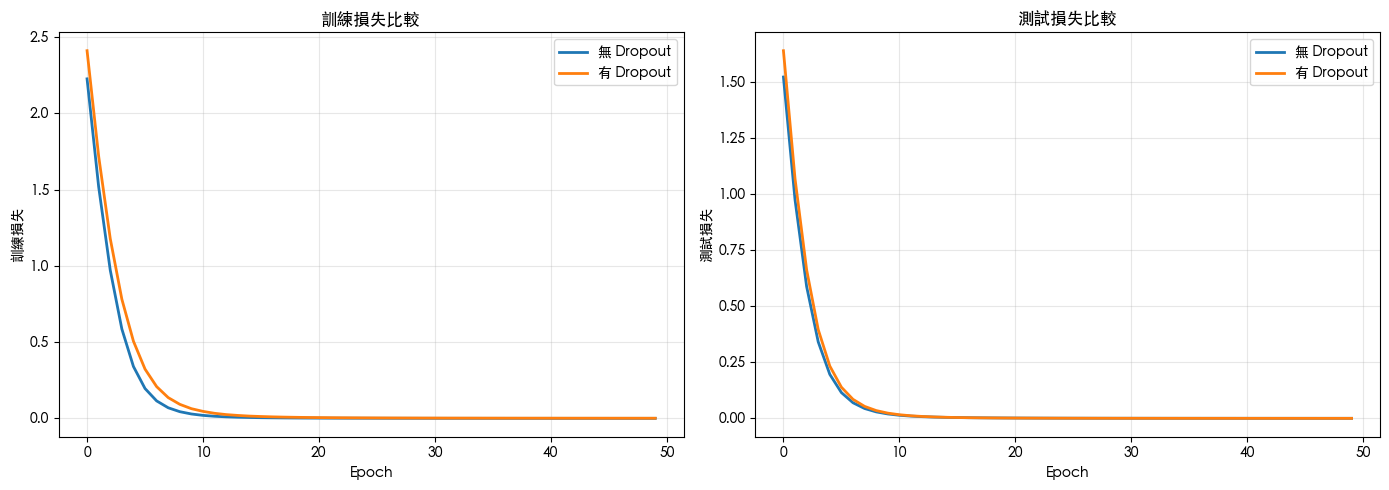


結果分析:
  無 Dropout 最終測試損失: 0.0004
  有 Dropout 最終測試損失: 0.0003


In [28]:
# 視覺化訓練結果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 訓練損失
ax1.plot(train_loss_no, label='無 Dropout', linewidth=2)
ax1.plot(train_loss_with, label='有 Dropout', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('訓練損失')
ax1.set_title('訓練損失比較')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 測試損失
ax2.plot(test_loss_no, label='無 Dropout', linewidth=2)
ax2.plot(test_loss_with, label='有 Dropout', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('測試損失')
ax2.set_title('測試損失比較')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dropout_training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n結果分析:")
print(f"  無 Dropout 最終測試損失: {test_loss_no[-1]:.4f}")
print(f"  有 Dropout 最終測試損失: {test_loss_with[-1]:.4f}")

## 8. Dropout 位置圖解

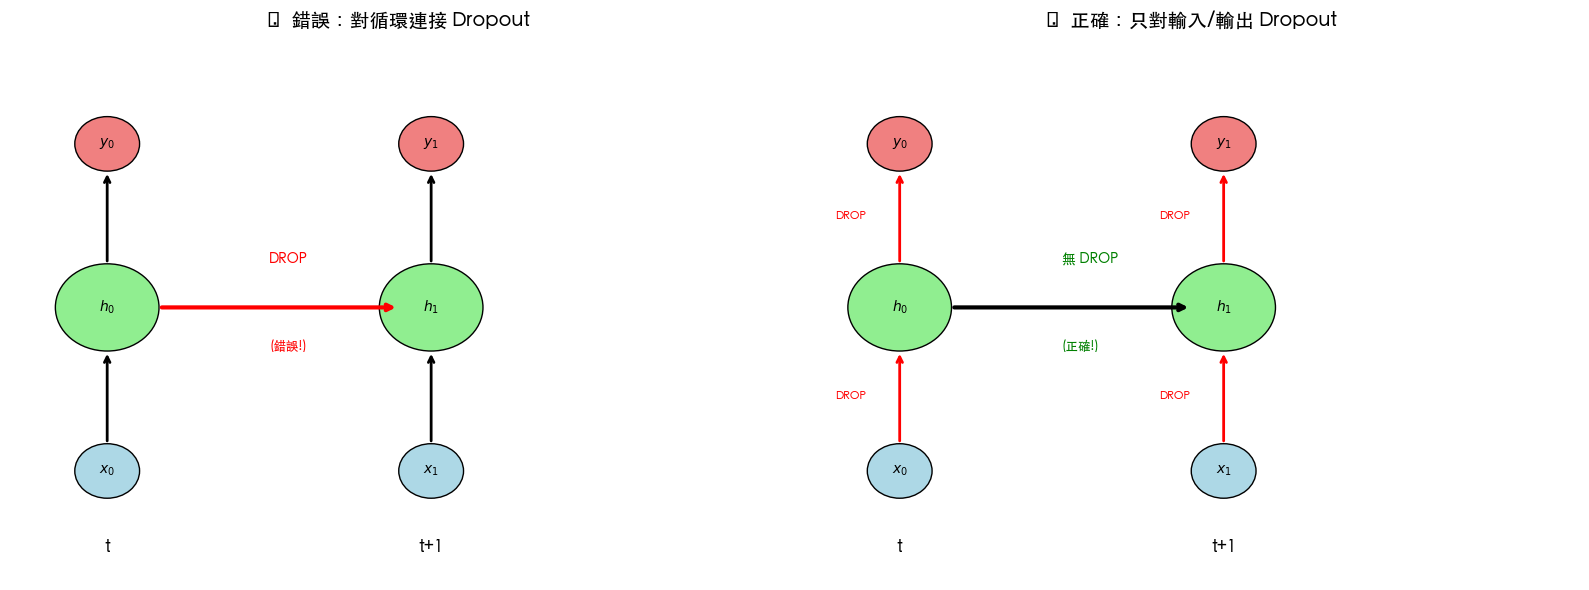

In [29]:
def draw_rnn_dropout_diagram():
    """繪製 RNN dropout 位置圖解"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for ax, title, correct in [(axes[0], '❌ 錯誤：對循環連接 Dropout', False),
                                (axes[1], '✓ 正確：只對輸入/輸出 Dropout', True)]:
        ax.set_xlim(0, 12)
        ax.set_ylim(0, 10)
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')
        
        # 繪製兩個時間步
        for i, t in enumerate([0, 1]):
            x_offset = i * 5
            
            # 輸入 x_t
            ax.add_patch(plt.Circle((1.5 + x_offset, 2), 0.5, color='lightblue', ec='black'))
            ax.text(1.5 + x_offset, 2, f'$x_{t}$', ha='center', va='center', fontsize=10)
            
            # 隱藏狀態 h_t
            ax.add_patch(plt.Circle((1.5 + x_offset, 5), 0.8, color='lightgreen', ec='black'))
            ax.text(1.5 + x_offset, 5, f'$h_{t}$', ha='center', va='center', fontsize=10)
            
            # 輸出 y_t
            ax.add_patch(plt.Circle((1.5 + x_offset, 8), 0.5, color='lightcoral', ec='black'))
            ax.text(1.5 + x_offset, 8, f'$y_{t}$', ha='center', va='center', fontsize=10)
            
            # 輸入到隱藏的箭頭
            color = 'red' if correct else 'black'
            ax.annotate('', xy=(1.5 + x_offset, 4.2), xytext=(1.5 + x_offset, 2.5),
                       arrowprops=dict(arrowstyle='->', color=color, lw=2))
            if correct:
                ax.text(0.5 + x_offset, 3.3, 'DROP', color='red', fontsize=8, fontweight='bold')
            
            # 隱藏到輸出的箭頭
            ax.annotate('', xy=(1.5 + x_offset, 7.5), xytext=(1.5 + x_offset, 5.8),
                       arrowprops=dict(arrowstyle='->', color=color, lw=2))
            if correct:
                ax.text(0.5 + x_offset, 6.6, 'DROP', color='red', fontsize=8, fontweight='bold')
        
        # 循環連接箭頭
        recurrent_color = 'red' if not correct else 'black'
        ax.annotate('', xy=(6, 5), xytext=(2.3, 5),
                   arrowprops=dict(arrowstyle='->', color=recurrent_color, lw=3))
        
        if not correct:
            ax.text(4, 5.8, 'DROP', color='red', fontsize=10, fontweight='bold')
            ax.text(4, 4.2, '(錯誤!)', color='red', fontsize=9)
        else:
            ax.text(4, 5.8, '無 DROP', color='green', fontsize=10, fontweight='bold')
            ax.text(4, 4.2, '(正確!)', color='green', fontsize=9)
        
        # 時間標籤
        ax.text(1.5, 0.5, 't', ha='center', fontsize=12)
        ax.text(6.5, 0.5, 't+1', ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('dropout_position_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()

draw_rnn_dropout_diagram()

## 9. 總結

### 核心要點

| 策略 | 輸入連接 | 循環連接 | 輸出連接 | 效果 |
|------|----------|----------|----------|------|
| 無 Dropout | - | - | - | 容易過擬合 |
| 錯誤 Dropout | ✓ | ✓ | ✓ | 破壞時間資訊 |
| **正確 Dropout** | ✓ | ✗ | ✓ | **最佳效果** |
| 變分 Dropout | ✓(一致) | ✗ | ✓(一致) | 更穩定 |

### PyTorch 實作提示

1. `nn.LSTM(dropout=0.5)` 會在**層與層之間**應用 dropout
2. 需要手動對**輸入嵌入**和**最終輸出**應用 dropout
3. 變分 dropout 需要自己實作

In [30]:
print("第四章完成！")
print("\n我們學到了：")
print("  1. 為什麼天真地對 RNN 應用 dropout 不管用")
print("  2. Zaremba et al. 的正確 dropout 位置")
print("  3. 變分 dropout 的原理和實作")
print("  4. PyTorch 中如何正確使用 LSTM dropout")
print("\n下一章：Neural Machine Translation!")

第四章完成！

我們學到了：
  1. 為什麼天真地對 RNN 應用 dropout 不管用
  2. Zaremba et al. 的正確 dropout 位置
  3. 變分 dropout 的原理和實作
  4. PyTorch 中如何正確使用 LSTM dropout

下一章：Neural Machine Translation!
